# Statistical Analysis of Pupil Data

```{admonition} Overview
PupEyes is designed for **preprocessing**: preparing your data in an analysis-friendly format so you can perform whatever analyses that you deem appropriate for your research goals. Indeed, there are [many ways to analyze pupil size data](https://link.springer.com/book/10.1007/978-3-031-54896-3), and it would be impractical to implement them all. We will use some basic examples to demonstrate how easily you can conduct analyses with preprocessed `PupEyes` data.

We'll cover two basic approaches to analyzing task-evoked pupillary responses:

1. **Using a Predefined Time Window**

2. **Plotting Evoked Responses**

3. **Cluster-based Permutation Testing**

```

```{note} 
Some analyses in this tutorial require the `mne` package, a Python library for visualizing and analyzing neurophysiological data. `mne` is not included as a dependency for PupEyes. For information on how to install, see: https://mne.tools/stable/install/index.html
```

## Load Data

We will load our preprocessed data from the [Pupil Preprocessing](pupil_preproc.ipynb) tutorial.

In [24]:
import pandas as pd
import pupeyes as pe

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# For a between-subject design:
data_between = pe.generate_pupil_data(
    n_participants=6,
    n_trials=40,
    design_type='between',
    condition_effect=0.3
)

# For a within-subject design:
data_within = pe.generate_pupil_data(
    n_participants=6,
    n_trials=40,
    design_type='within',
    condition_effect=0.3
)

In [38]:
p = pe.PupilProcessor(
    data=data_between,
    trial_identifier=['participant', 'trial'],
    x_col = 'x',
    y_col = 'y',
    pupil_col = 'pp',
    time_col = 'trialtime',
    samp_freq = 1000,
    convert_pupil_size=False,
    progress_bar=False
    )\
    .deblink()\
    .artifact_rejection()\
    .filter_position(vertices= [(0,0), (0, 1080), (1920, 1080), (1920, 0), (0,0)])\
    .smooth()\
    .check_missing()\
    .interpolate(missing_threshold=.4)\
    .baseline_correction(baseline_query='event=="fixation"', baseline_range=[-10, None])

Sampling frequency check passed.
PupilProcessor initialized with 720000 samples
Pupil column: pp, Time column: trialtime, X column: x, Y column: y
Trial identifier: ['participant', 'trial'], Number of trials: 240


In [16]:
viewer = pe.PupilViewer(p, hue='event')
viewer.run_server()

In [39]:
# 1. Create a final dataset with only valid trials during stimulus presentation
p.final_data = p.data.query('event=="stimulus"').reset_index(drop=True)

# 2. Rename the fully preprocessed pupil column to something more manageable
p.final_data['pp_final'] = p.final_data['pp_db_ar_xy_sm_it_bc']

# 3. Select only the relevant columns for analysis
p.final_data = p.final_data[[
    'condition',    # condition
    'participant',  # participant ID
    'trial',        # trial number
    'event',        # event marker
    'trialtime',    # time relative to trial onset
    'x', 'y',       # gaze coordinates
    'pp_final'      # preprocessed pupil size
]]

# 4. Create a timestamp column indicating time since stimulus onset using pandas' groupby-transform routine
p.final_data['eventtime'] = p.final_data.groupby(['participant','trial']).trialtime.transform(lambda x: x - x.iloc[0]) # reset timestamp for each trial

# Preview the data
p.final_data

,condition,participant,trial,event,trialtime,x,y,pp_final,eventtime
0,B,P1,1,stimulus,500,957.498663,539.817902,0.004446,0
1,B,P1,1,stimulus,501,974.461899,531.059259,0.005271,1
2,B,P1,1,stimulus,502,951.849407,509.399102,0.006109,2
3,B,P1,1,stimulus,503,976.50112,550.968139,0.006962,3
4,B,P1,1,stimulus,504,912.108777,524.333068,0.007831,4
...,...,...,...,...,...,...,...,...,...
599995,A,P6,40,stimulus,2995,948.355019,531.966984,-0.138909,2495
599996,A,P6,40,stimulus,2996,1000.168527,500.335457,-0.138909,2496
599997,A,P6,40,stimulus,2997,949.927468,513.919318,-0.138909,2497
599998,A,P6,40,stimulus,2998,947.120328,526.191457,-0.138909,2498


## Use a Predefined Time Window

If you have a hypothesis for when your task-evoked pupillary response will emerge, you can simply select that time window and compute the mean pupil size within that window.

For example, if we hypothesize that the effect emerges during 600 ms to 1000 ms after stimulus onset:

In [33]:
p.after600 = p.final_data.query('eventtime > 600 & eventtime < 1000').groupby(['condition','participant','trial']).pp_final.mean() 
p.after600

condition  participant  trial
A          P4           1        0.324281
                        2        0.265861
                        3        0.527059
                        4        0.194526
                        5        0.115761
                                   ...   
B          P3           36       0.348355
                        37       0.409826
                        38       0.494495
                        39       0.238997
                        40       0.546527
Name: pp_final, Length: 240, dtype: Float64

From now on, mean pupil sizes can be analyzed in the same way as response times (RTs).

## Plot Evoked Response

Oftentimes we do not have a hypothesis about when an effect should emerge. Even if we do, it is always nice to have a plot showing the entire evoked response. PupEyes has a built-in method, `.plot_evoked()`, to plot evoked responses. 

Here, we plot the task-evoked response separately for groups A and B.

Data will be padded to minimum length: 2500 samples
Condition {'condition': 'B'}: Computing average from 120 trials
Condition {'condition': 'A'}: Computing average from 120 trials


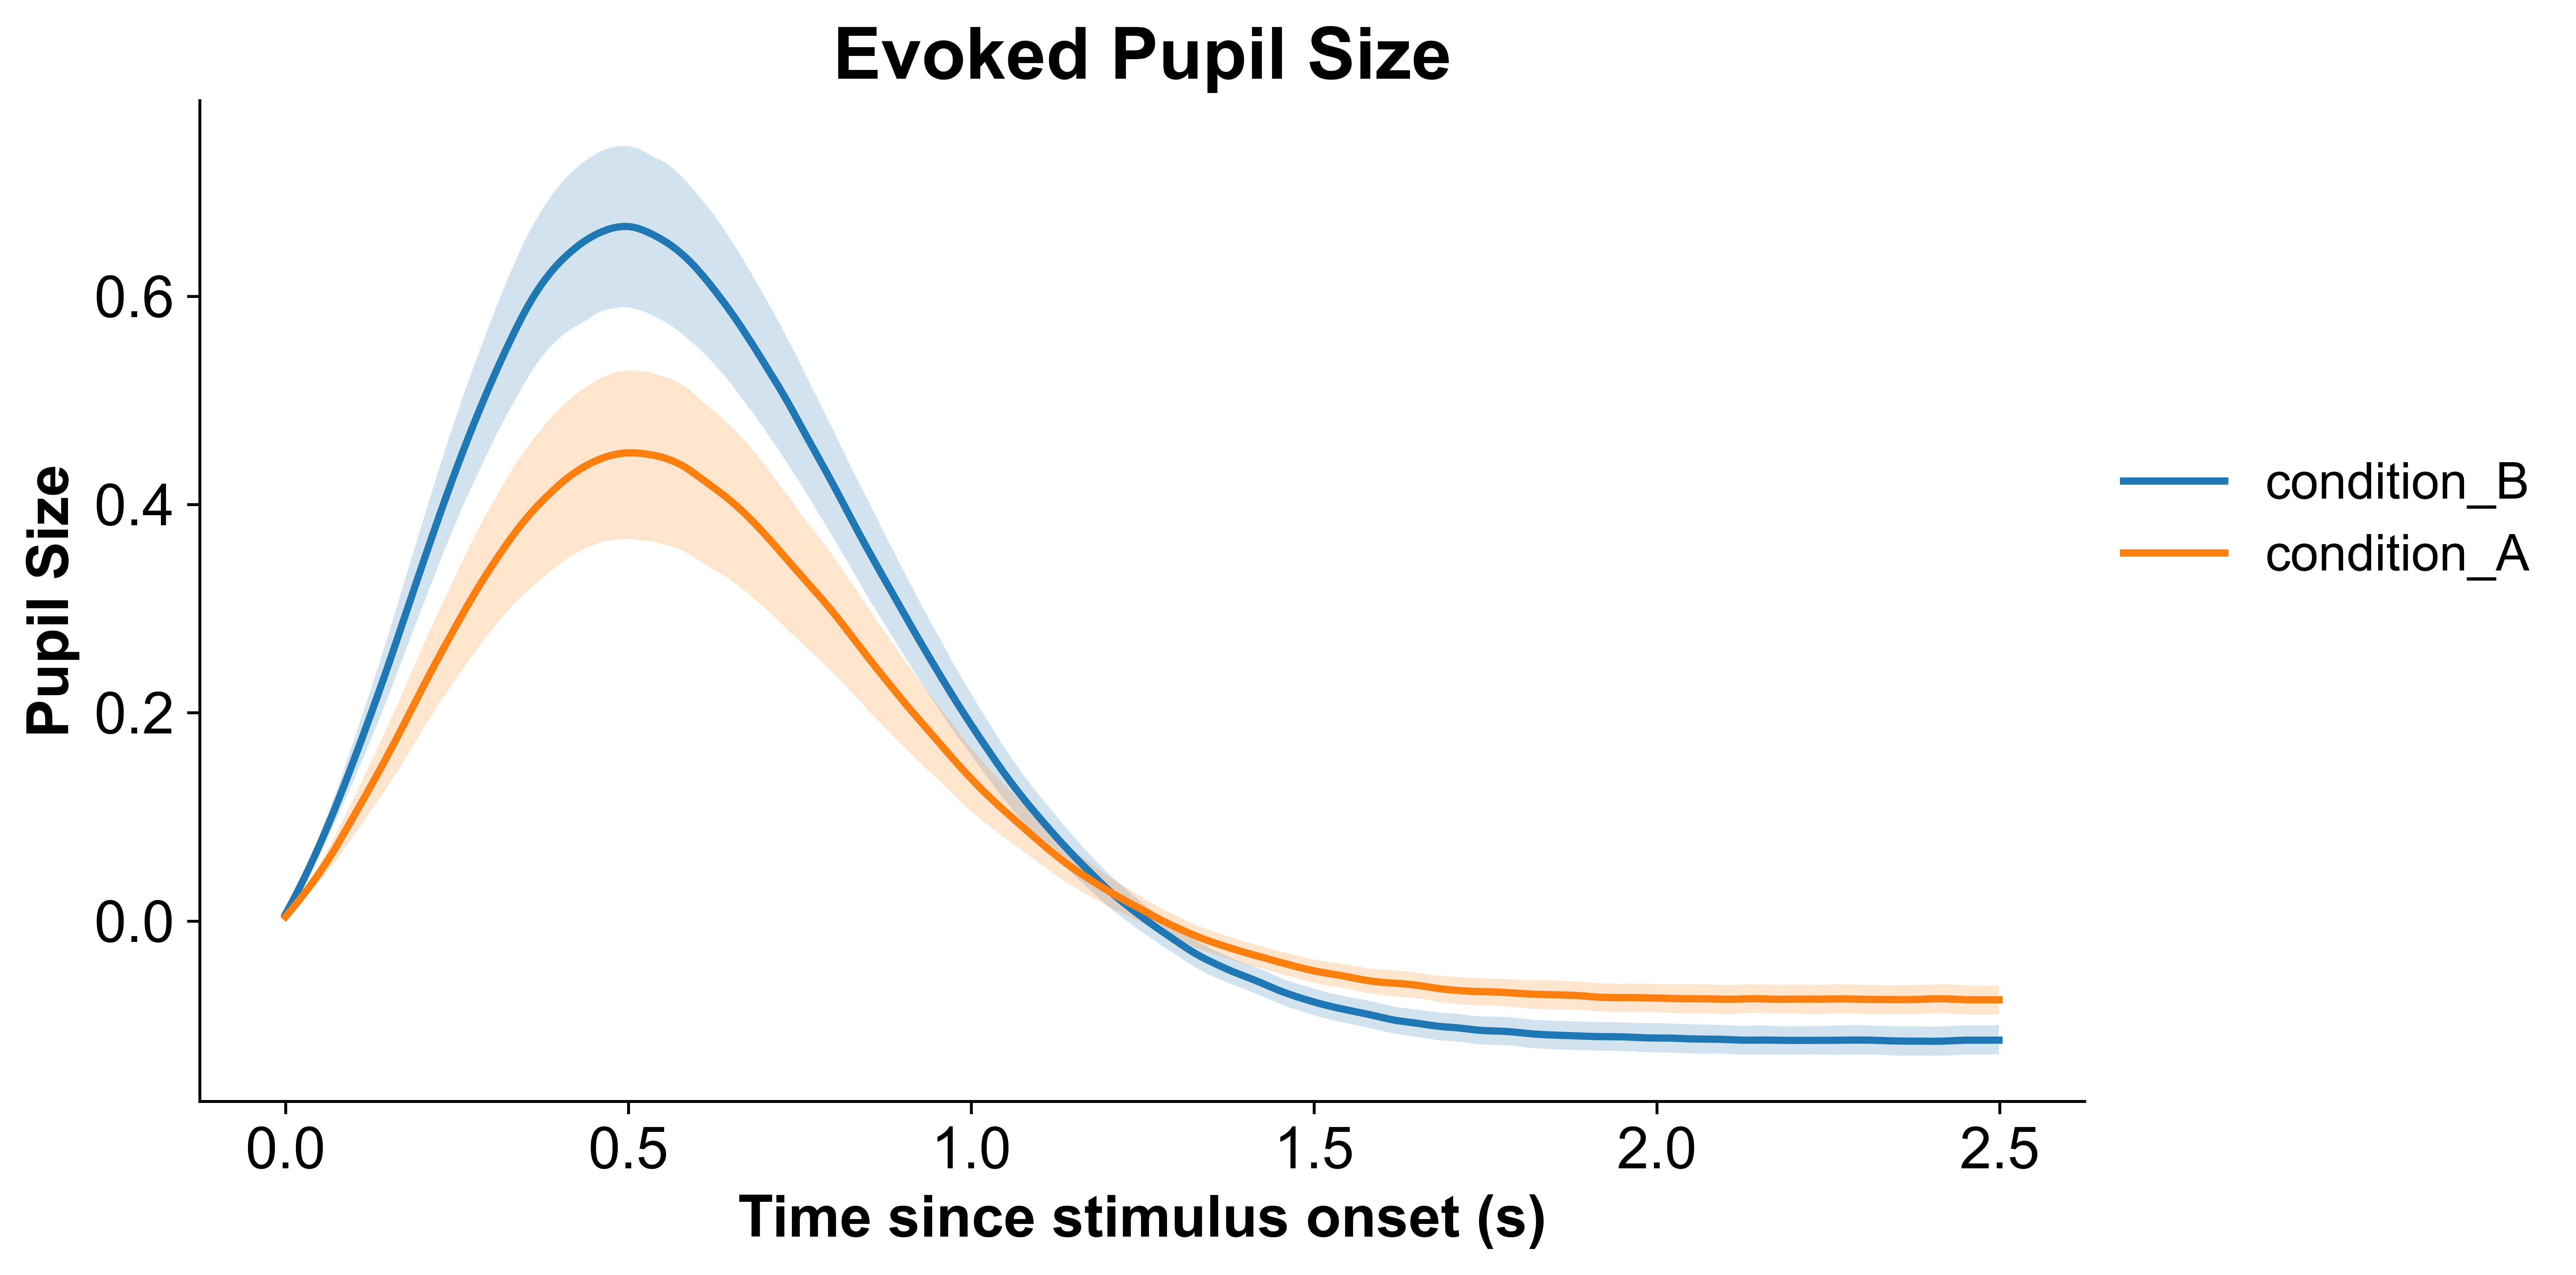

In [40]:
data, (fig, ax) = p.plot_evoked(data='final_data', 
                                condition='condition', # supports plotting separately
                                pupil_col='pp_final', 
                                error='ci')

With `.plot_evoked()`, there are many other visualizations that you can do. For example, we can plot the evoked response for individual participants:

Data will be padded to minimum length: 2500 samples
Condition {'condition': 'B', 'participant': 'P1'}: Computing average from 40 trials
Condition {'condition': 'B', 'participant': 'P2'}: Computing average from 40 trials
Condition {'condition': 'B', 'participant': 'P3'}: Computing average from 40 trials
Condition {'condition': 'A', 'participant': 'P4'}: Computing average from 40 trials
Condition {'condition': 'A', 'participant': 'P5'}: Computing average from 40 trials
Condition {'condition': 'A', 'participant': 'P6'}: Computing average from 40 trials


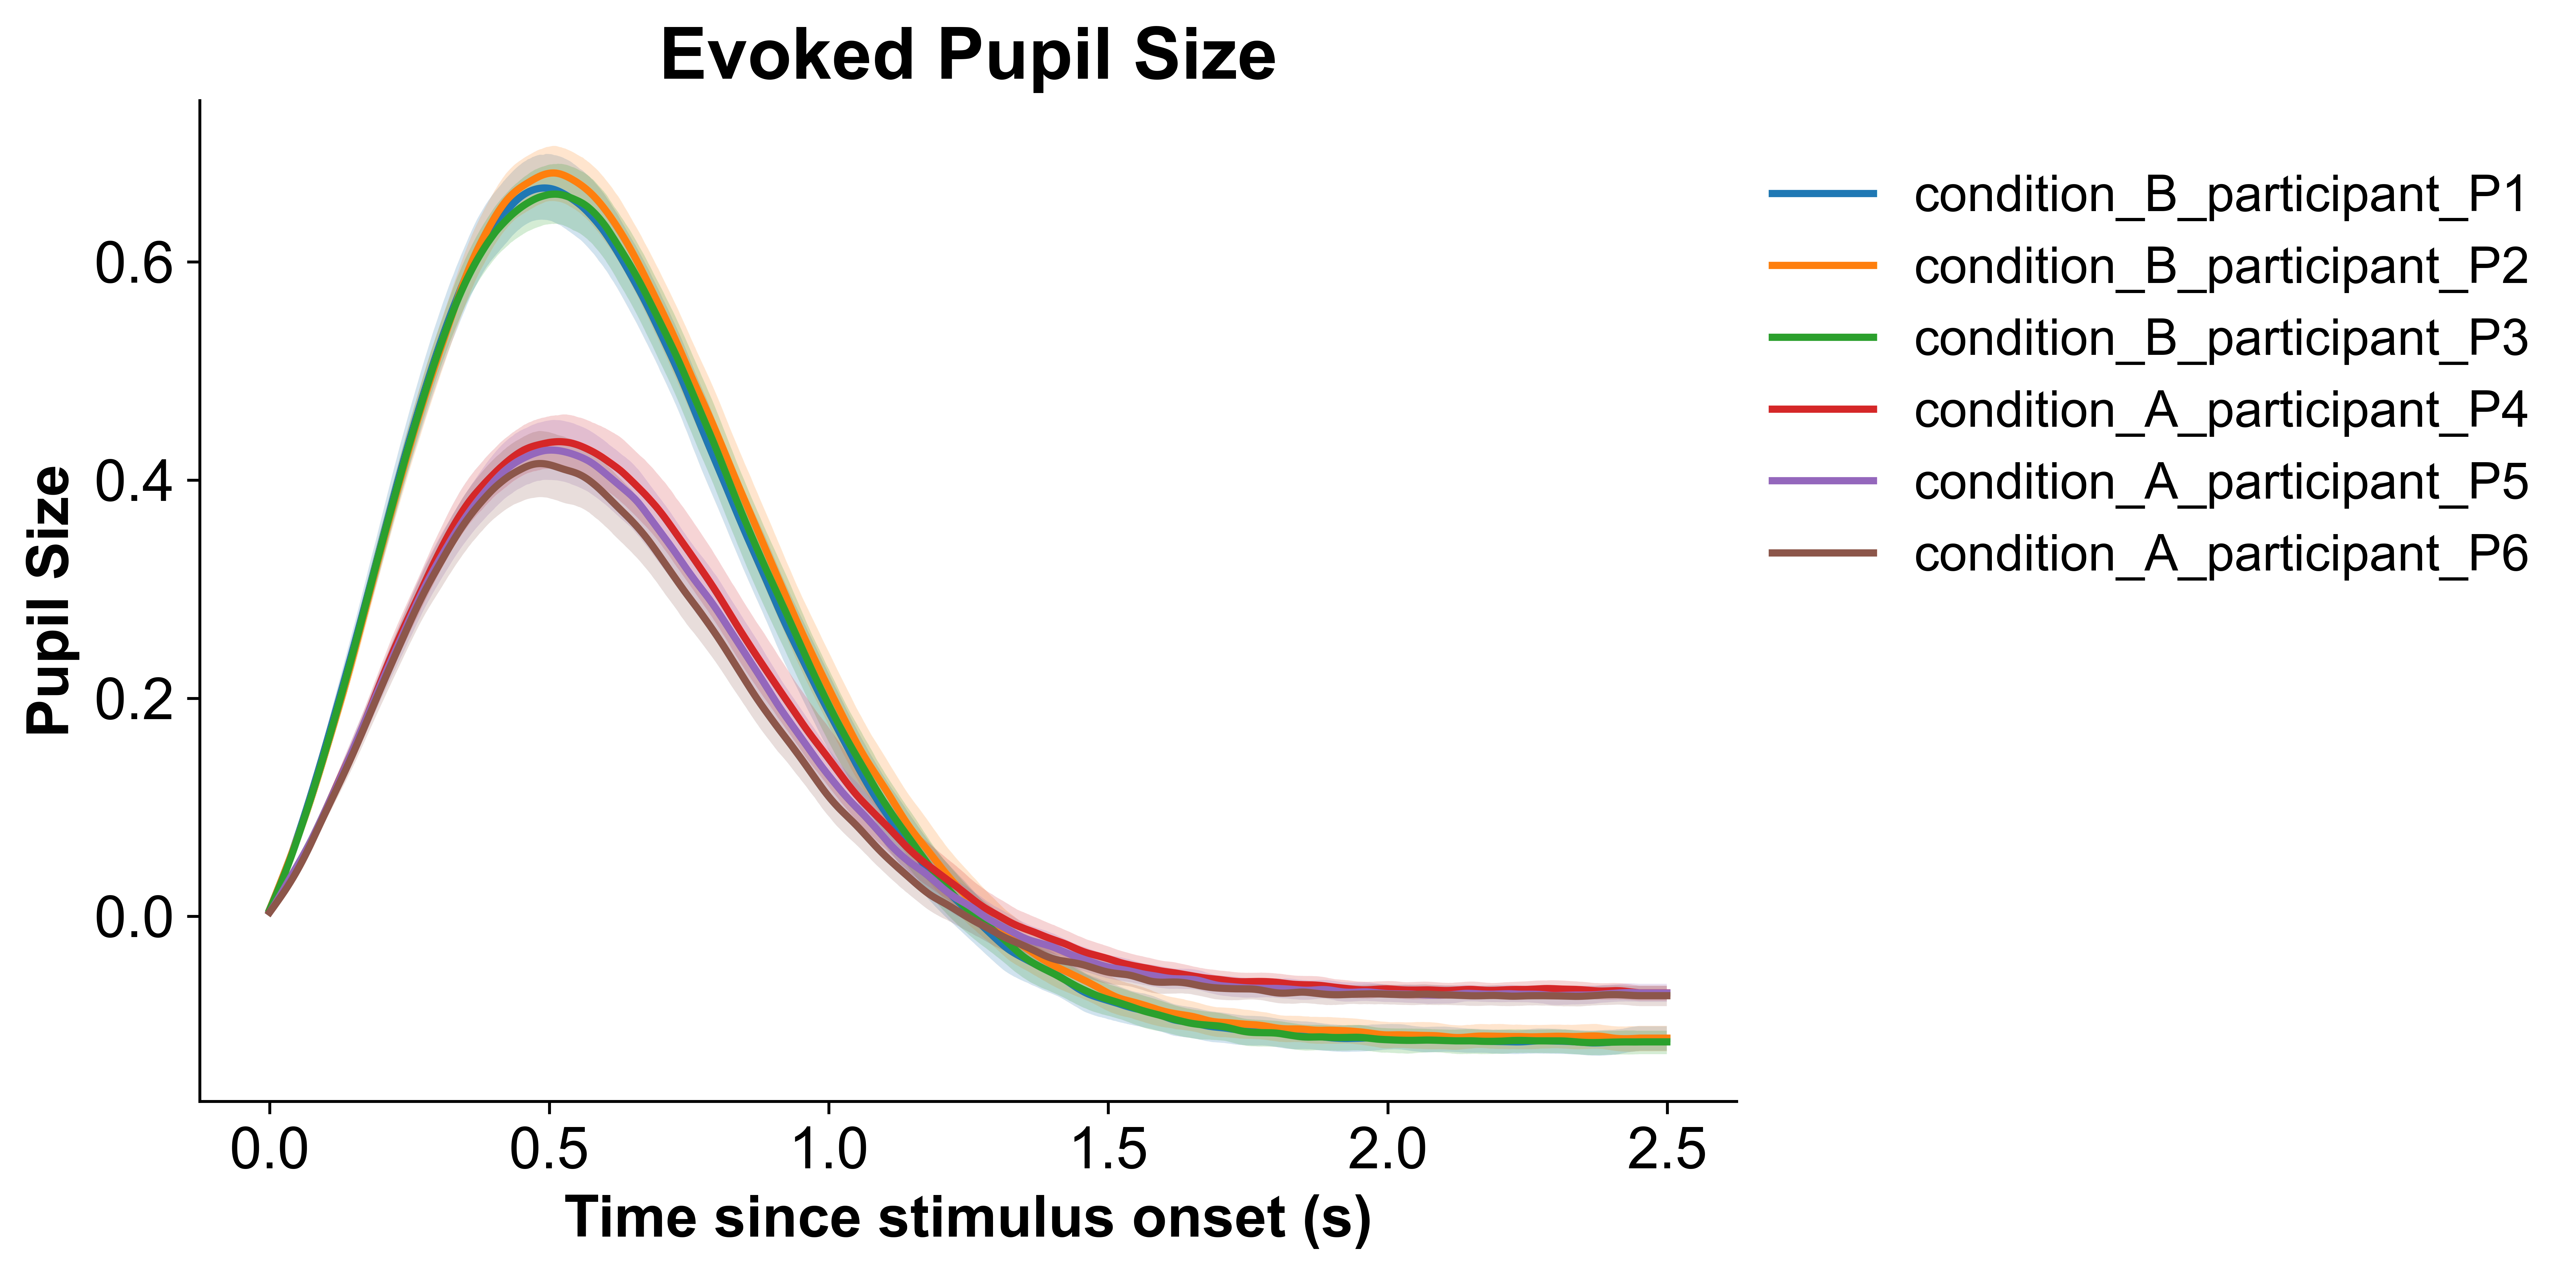

In [35]:
data, (fig, ax) = p.plot_evoked(data='final_data', 
                                condition=['condition','participant'], # supports adding a list
                                pupil_col='pp_final', 
                                error='ci')

You can also aggregate the data before plotting. For example, specifying `agg_by='participant'` will compute an averaged trace for each participant first and then plot the data based on participant-level traces, much like computing a mean RT for each participant and then plotting the average RT across participants.

Data will be padded to minimum length: 2500 samples
Condition {'condition': 'B'}: Computing average from 3 ['participant'] means
Condition {'condition': 'A'}: Computing average from 3 ['participant'] means


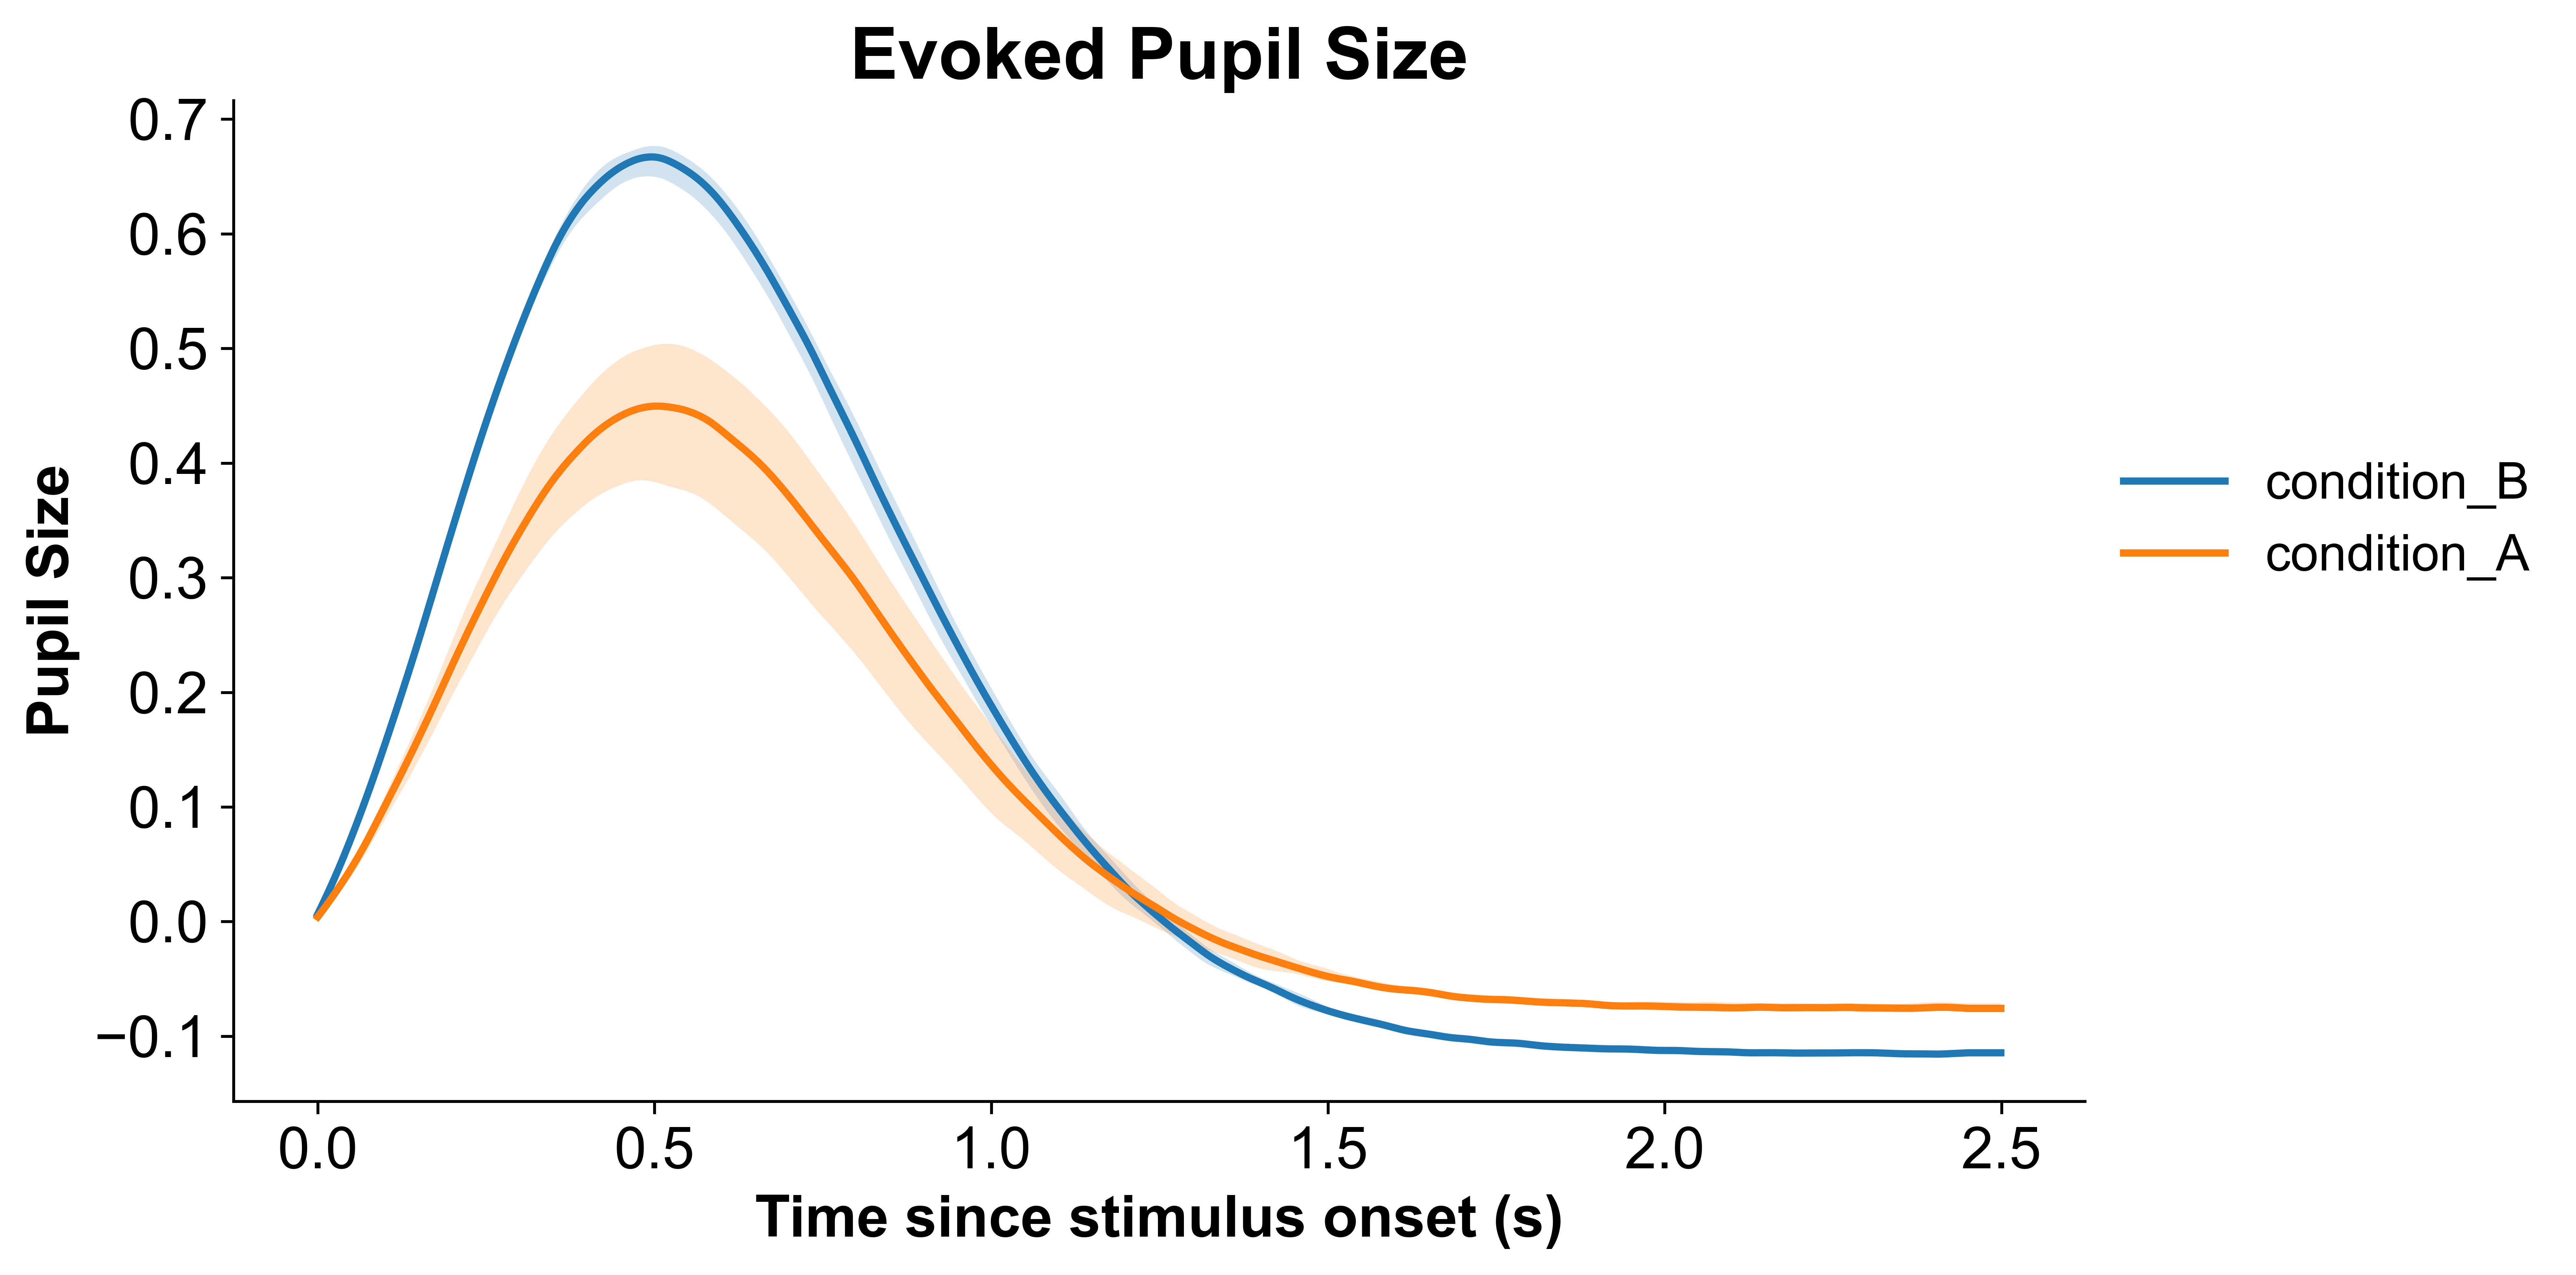

In [41]:
data, (fig, ax) = p.plot_evoked(data='final_data', 
                                agg_by='participant', # aggregate by participant
                                condition='condition', 
                                pupil_col='pp_final', 
                                error='ci')

## Cluster-based Permutation Testing

Pupil data easily consists of thousands of data points, which creates a multiple-comparison problem: If a statistical test is performed for every time point, it will easily end up having thousands of tests. Simply performing a Bonferroni correction seems too strict and limits statistical power. Therefore, it is common practice to conduct cluster-based permutation testing to determine whether the data is indistinguishable from chance (or from another condition).

### Difference from a Baseline

Below is an example of testing whether the task-evoked pupillary response in group `A` is distinguishable from 0. Remember that we only have 2 participants here, so this is purely for demonstration purposes.

In [112]:
import mne.stats as ms

Data will be padded to minimum length: 2997 samples
Computing average from 2 ['participant'] means


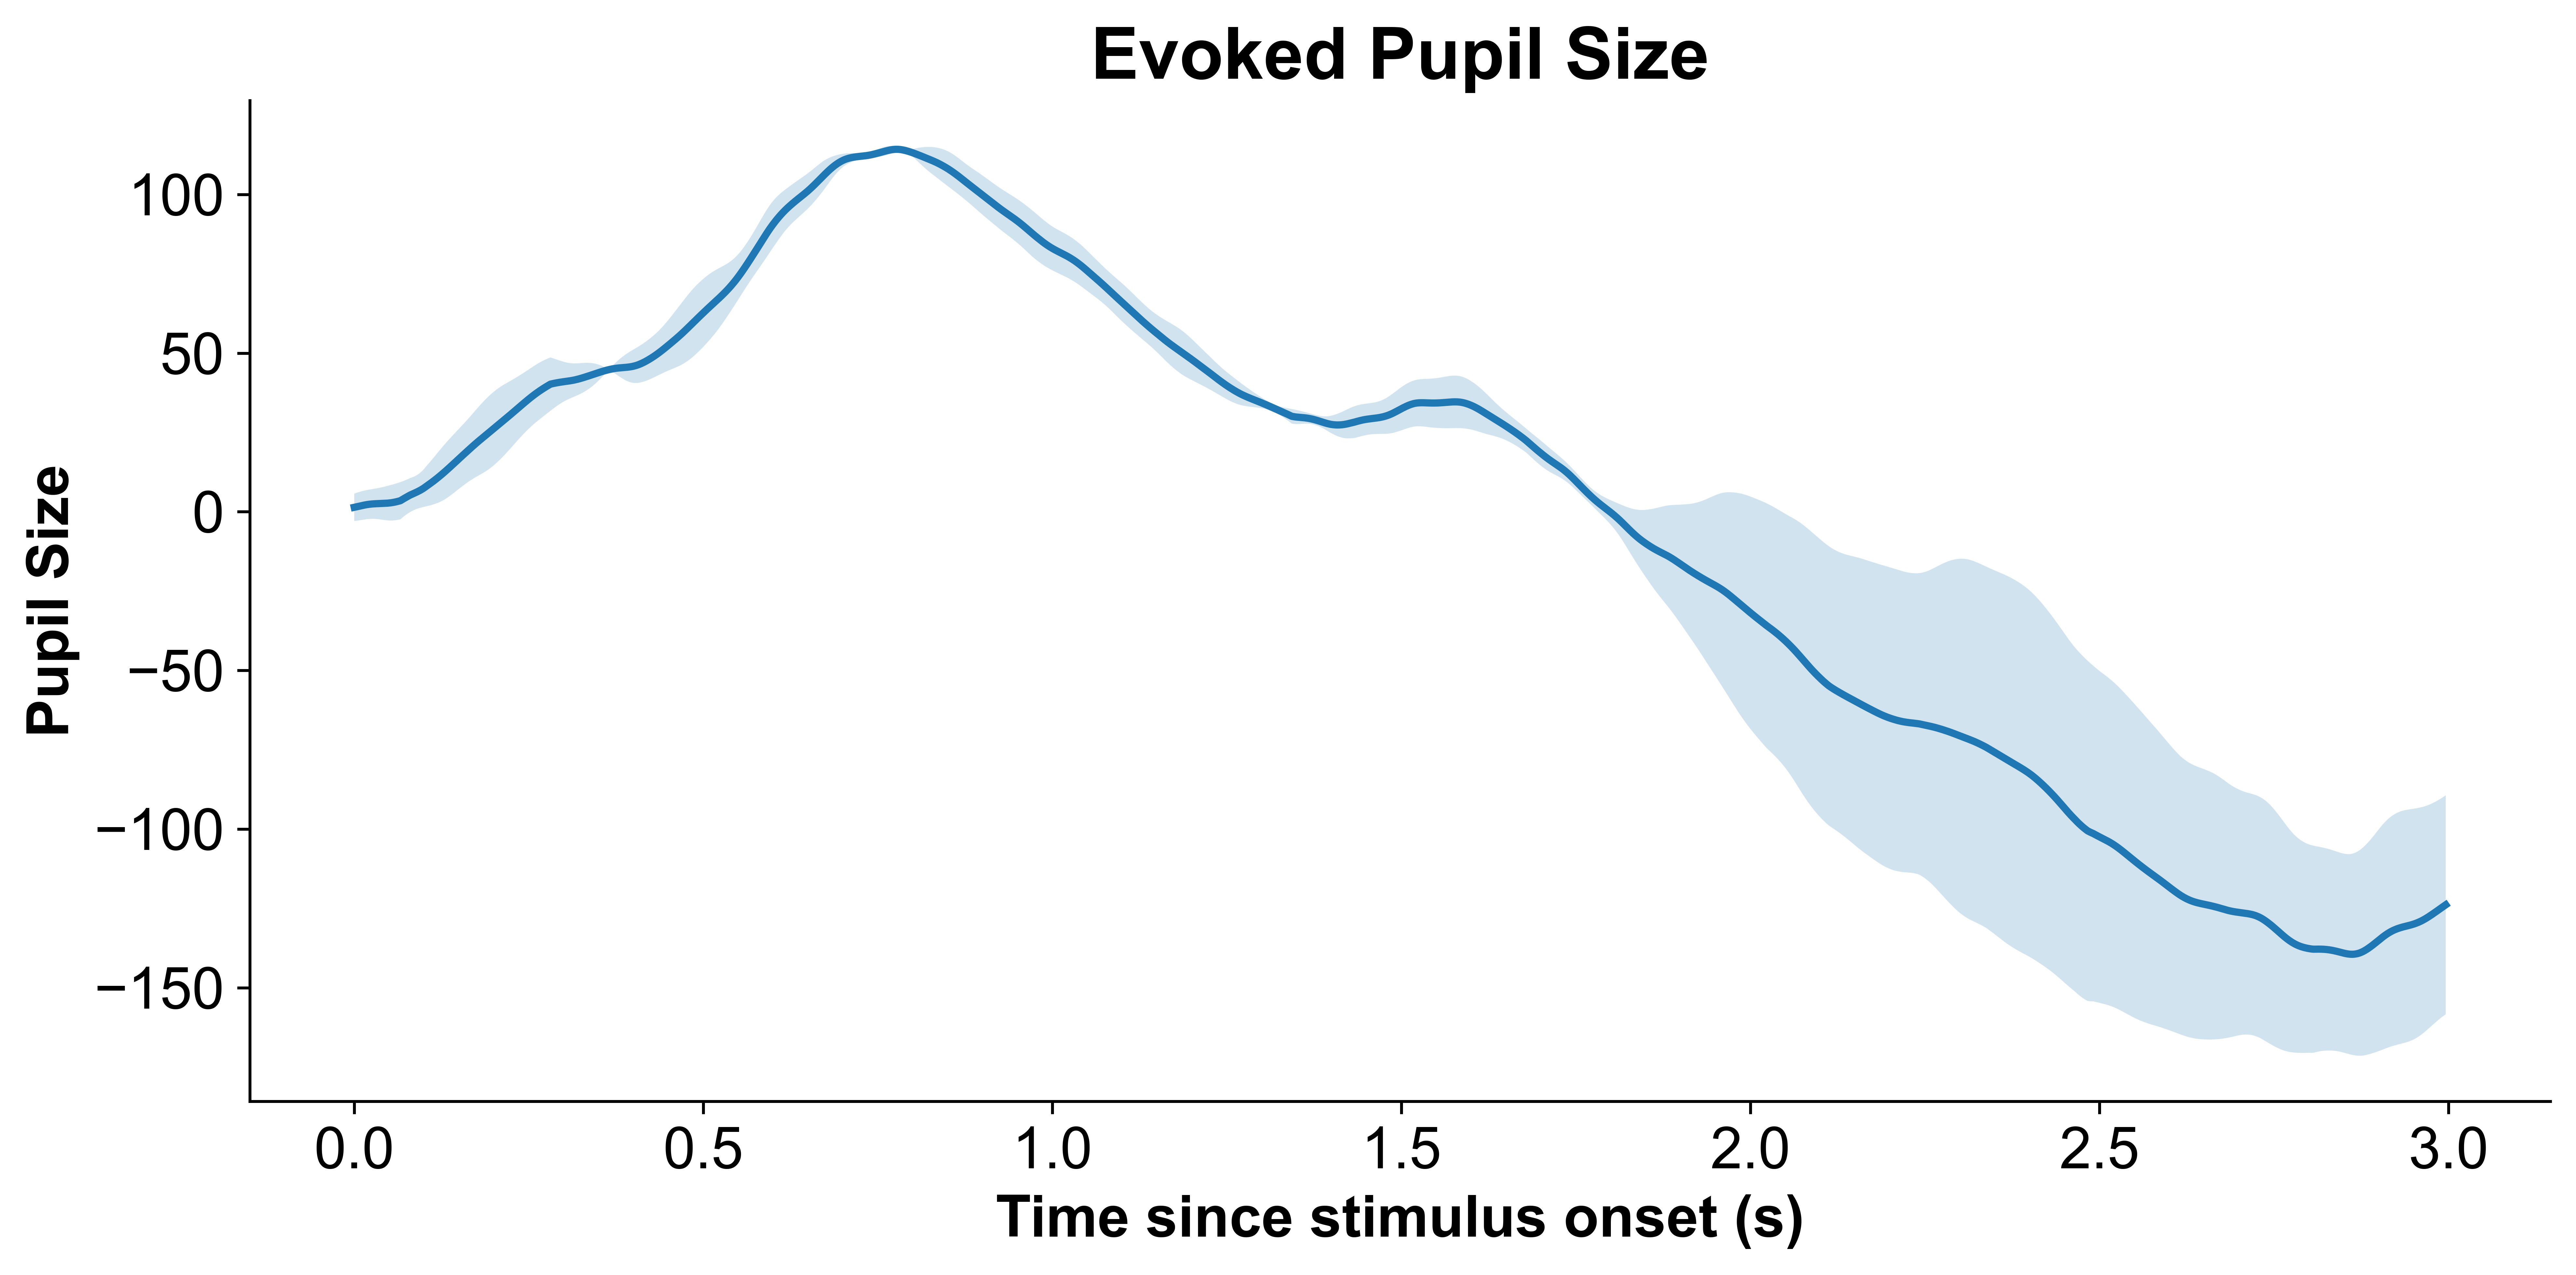

In [113]:
# we create a new data for group A only
p.groupAdata = p.final_data[p.final_data.group=='A']

# plot the evoked response but also get the data
data, (fig, ax) = p.plot_evoked(data='groupAdata', 
                                agg_by='participant', # aggregate by participant
                                pupil_col='pp_final', 
                                error='ci')

The `.plot_evoked()` method not only returns the plot but also the data that the plot is based on. In our example, the data is a 2*2997 array because we have 2 subjects with 2997 data points each. This returned data can be directly passed to `permutation_cluster_1samp_test` for a one-sample cluster-based permutation test. **The tests are completely handled by the `mne` package.**

In [114]:
data

{'all': array([[   5.70257443,    5.78394225,    5.86286222, ...,  -89.62461235,
          -89.4739812 ,  -89.32146127],
        [  -2.88636972,   -2.86985458,   -2.84971555, ..., -158.63212725,
         -158.47636613, -158.32434981]], shape=(2, 2997))}

In [115]:
# Cluster-based permutation test
T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_1samp_test(
    data['all'],
    n_permutations=1000,
    tail=0,
    n_jobs=-1,
    out_type="mask",
)

Using a threshold of 12.706205
stat_fun(H1): min=-4.435266005741488 max=4597.195384764446
Running initial clustering …
Found 3 clusters


C:\Users\Hans Cheng\AppData\Local\Temp\ipykernel_8364\1564048390.py:2: RuntimeWarning: joblib not installed. Cannot run in parallel.
  T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_1samp_test(
100%|██████████| Permuting (exact test) : 1/1 [00:00<00:00,  408.36it/s]


The test found 3 clusters, suggesting that there is a significant difference between the observed data and 0.

In [116]:
clusters

[(slice(344, 386, None),),
 (slice(604, 960, None),),
 (slice(1281, 1393, None),)]

We can also add a visualization of the found clusters to our original plot:

Data will be padded to minimum length: 2997 samples
Computing average from 2 ['participant'] means


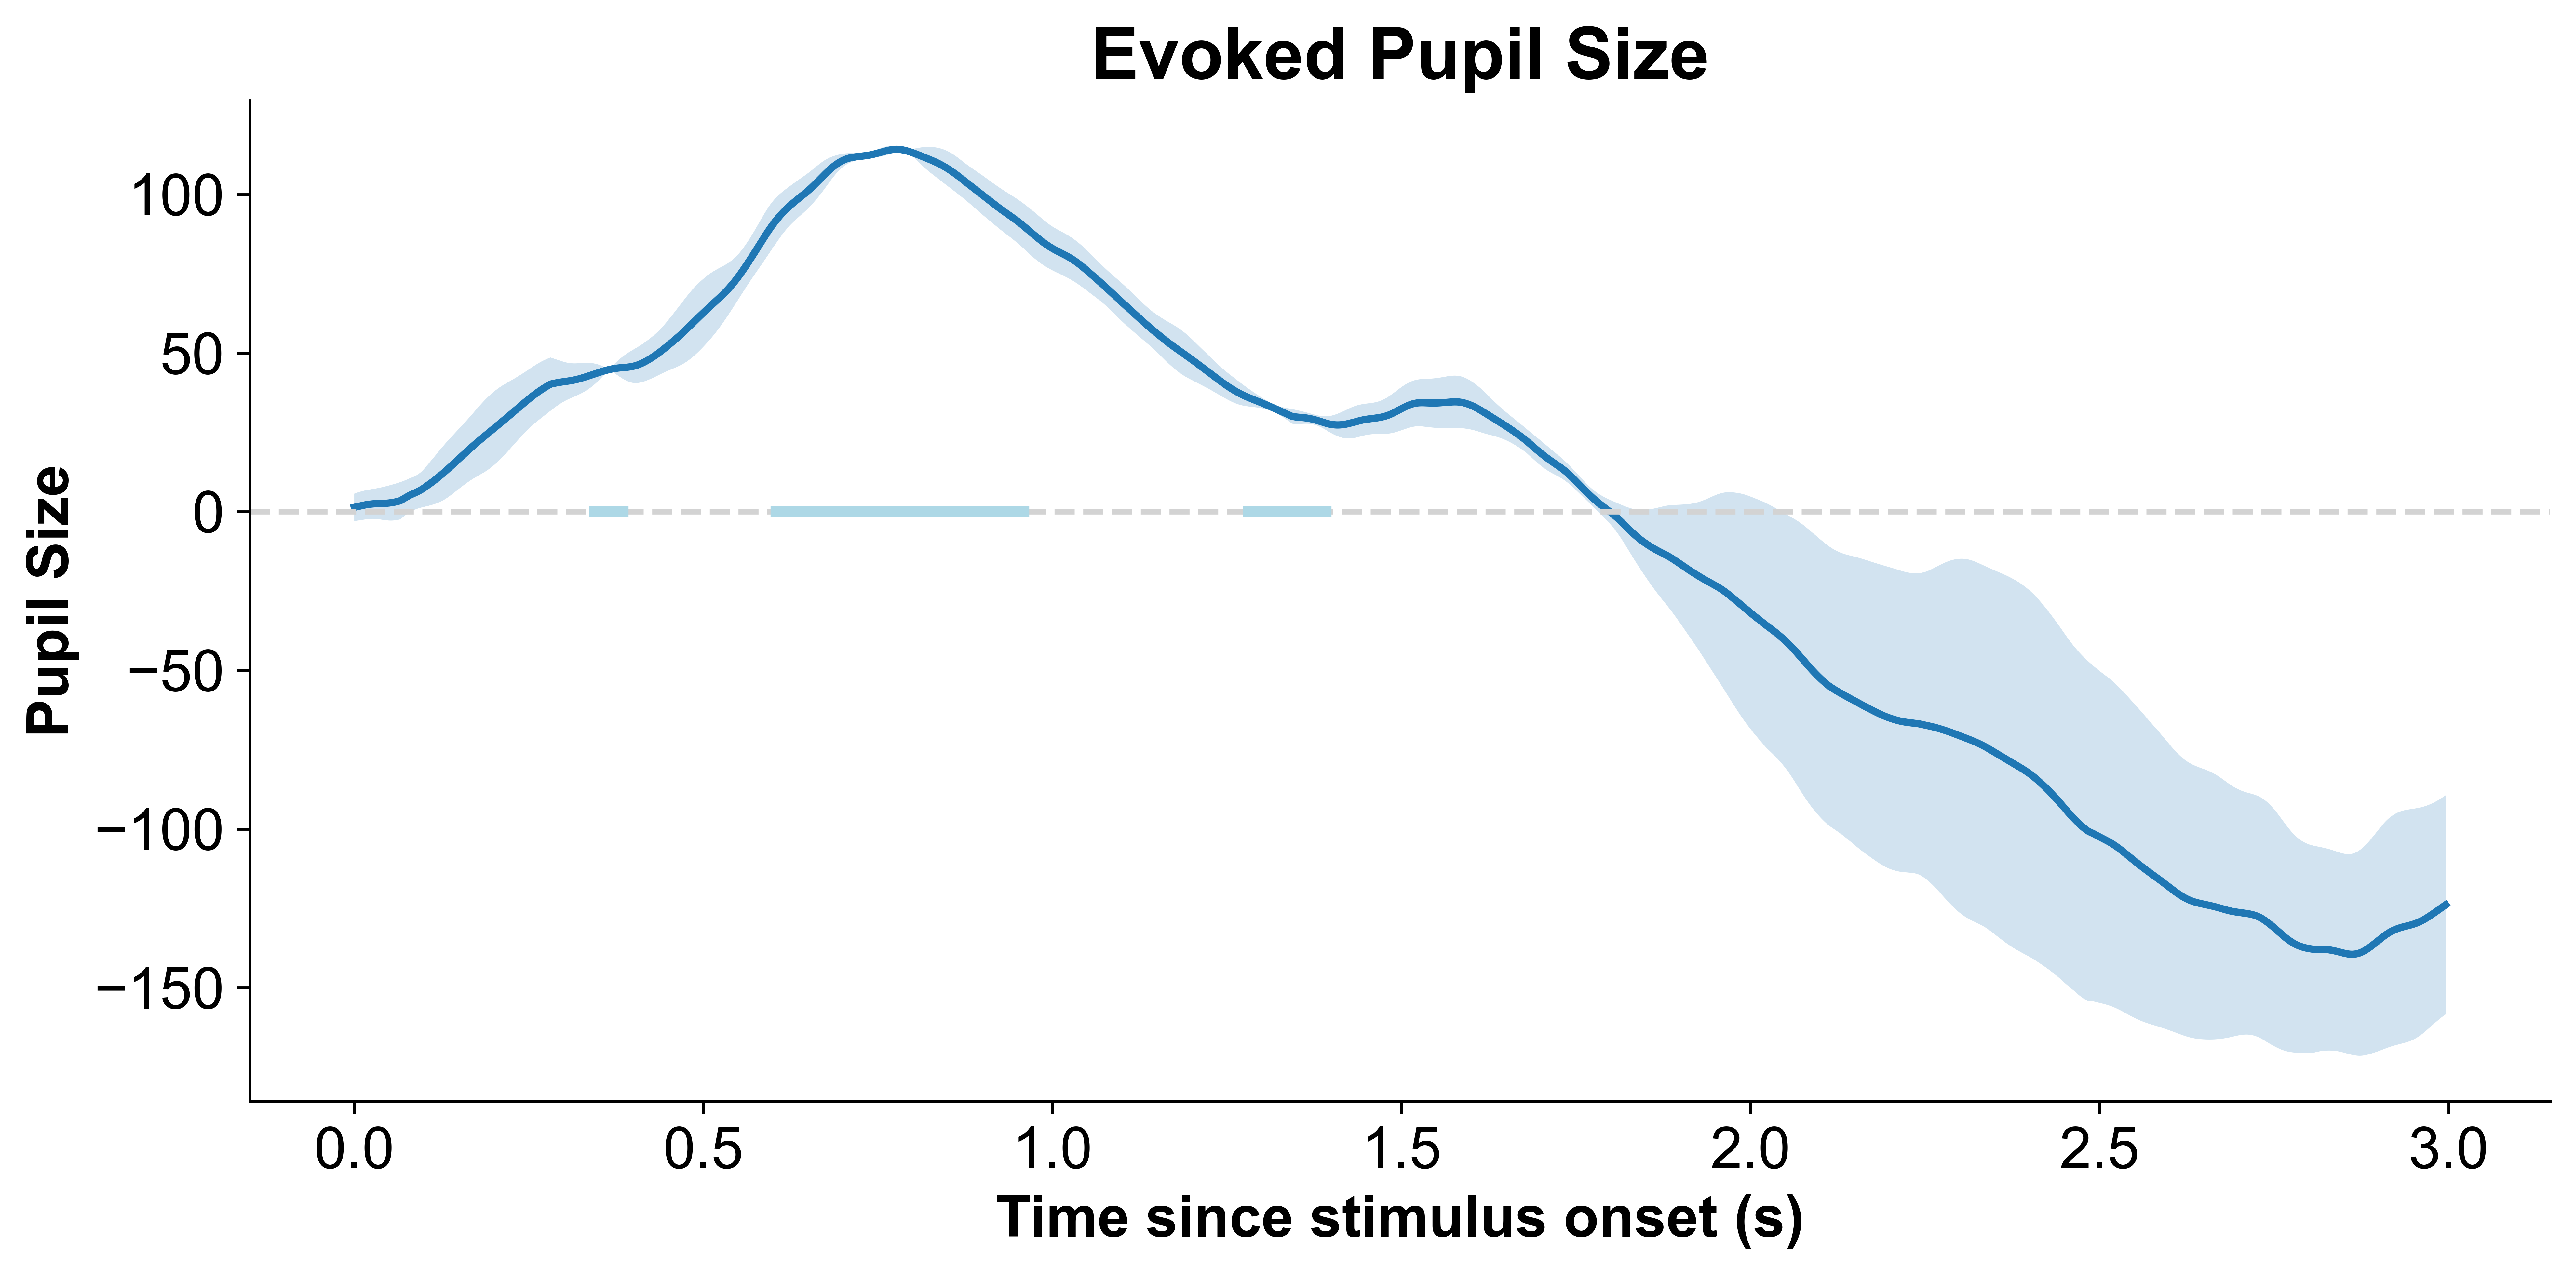

In [117]:
import matplotlib.pyplot as plt
import numpy as np

data, (fig, ax) = p.plot_evoked(data='groupAdata', 
                                agg_by='participant', # aggregate by participant
                                pupil_col='pp_final', 
                                error='ci')
# baseline
ax.axhline(0, color='lightgrey', linestyle='--')

# get timestamps
t = np.arange(data['all'].shape[1]) / 1000 # divided by sampling rate to get time vector

# plot clusters
for cluster in clusters:
    ax.plot(t[cluster], [0]*len(t[cluster]), color='lightblue', linewidth=3)

```{note}
1. For paired-sample t-tests, you would just pass an array of difference scores for each time point.

2. For further reading on permutation based t-tests, see:
- How not to interpret the results: https://www.fieldtriptoolbox.org/faq/stats/clusterstats_interpretation/
- `mne` API Reference: https://mne.tools/stable/generated/mne.stats.permutation_cluster_1samp_test.html
```

### Difference Between Conditions

It's pretty much the same as testing against a baseline, except that now the test is handled by `permutation_cluster_test()`. Note that by default, `permutation_cluster_test()` [uses a one-way ANOVA instead of an independent-sample t-test](https://mne.tools/stable/generated/mne.stats.permutation_cluster_test.html).

Data will be padded to minimum length: 2997 samples
Condition {'group': 'A'}: Computing average from 2 ['participant'] means
Condition {'group': 'B'}: Computing average from 2 ['participant'] means


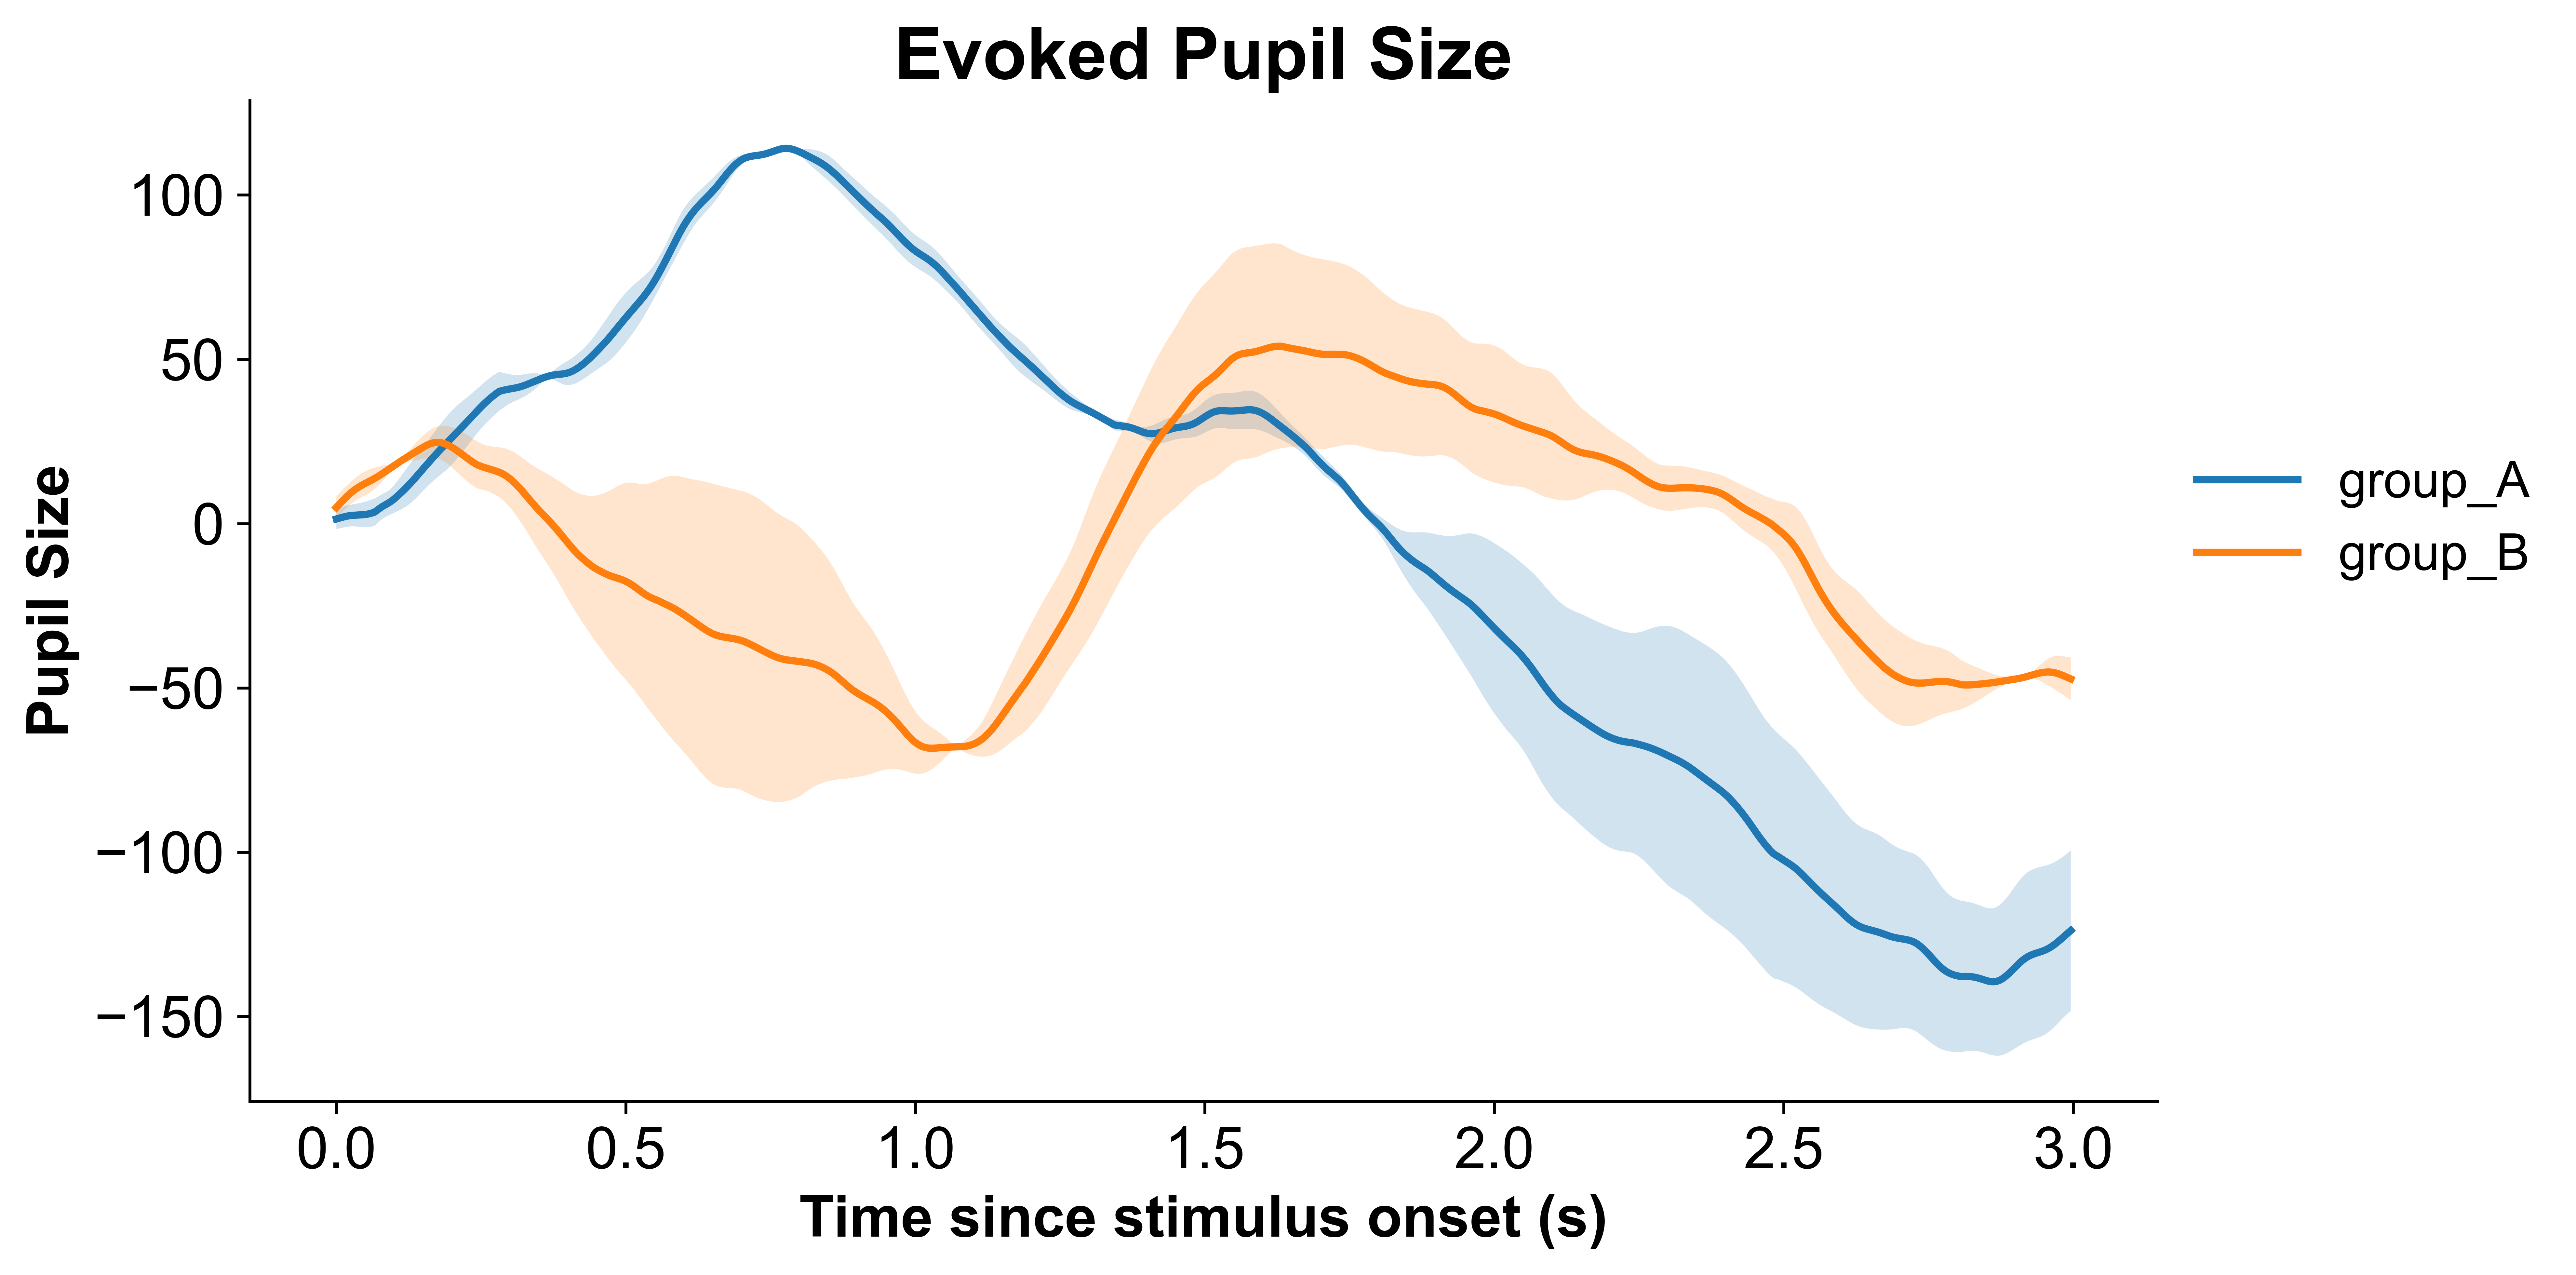

In [118]:
# plot an appropriate figure to get data
data, (fig, ax) = p.plot_evoked(data='final_data', 
                                agg_by='participant', # aggregate by participant
                                condition='group', 
                                pupil_col='pp_final', 
                                error='sem')

In [121]:
F_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_test(
    [data['group_A'], data['group_B']],
    n_permutations=1000,
    n_jobs=-1,
    out_type="mask",
)

Using a threshold of 18.512821
stat_fun(H1): min=4.215753045600406e-08 max=575.167166585092
Running initial clustering …
Found 1 cluster


C:\Users\Hans Cheng\AppData\Local\Temp\ipykernel_8364\1652210083.py:1: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  F_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_test(
C:\Users\Hans Cheng\AppData\Local\Temp\ipykernel_8364\1652210083.py:1: RuntimeWarning: joblib not installed. Cannot run in parallel.
  F_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_test(
100%|██████████| Permuting : 999/999 [00:00<00:00, 1033.34it/s]


Data will be padded to minimum length: 2997 samples
Condition {'group': 'A'}: Computing average from 2 ['participant'] means
Condition {'group': 'B'}: Computing average from 2 ['participant'] means


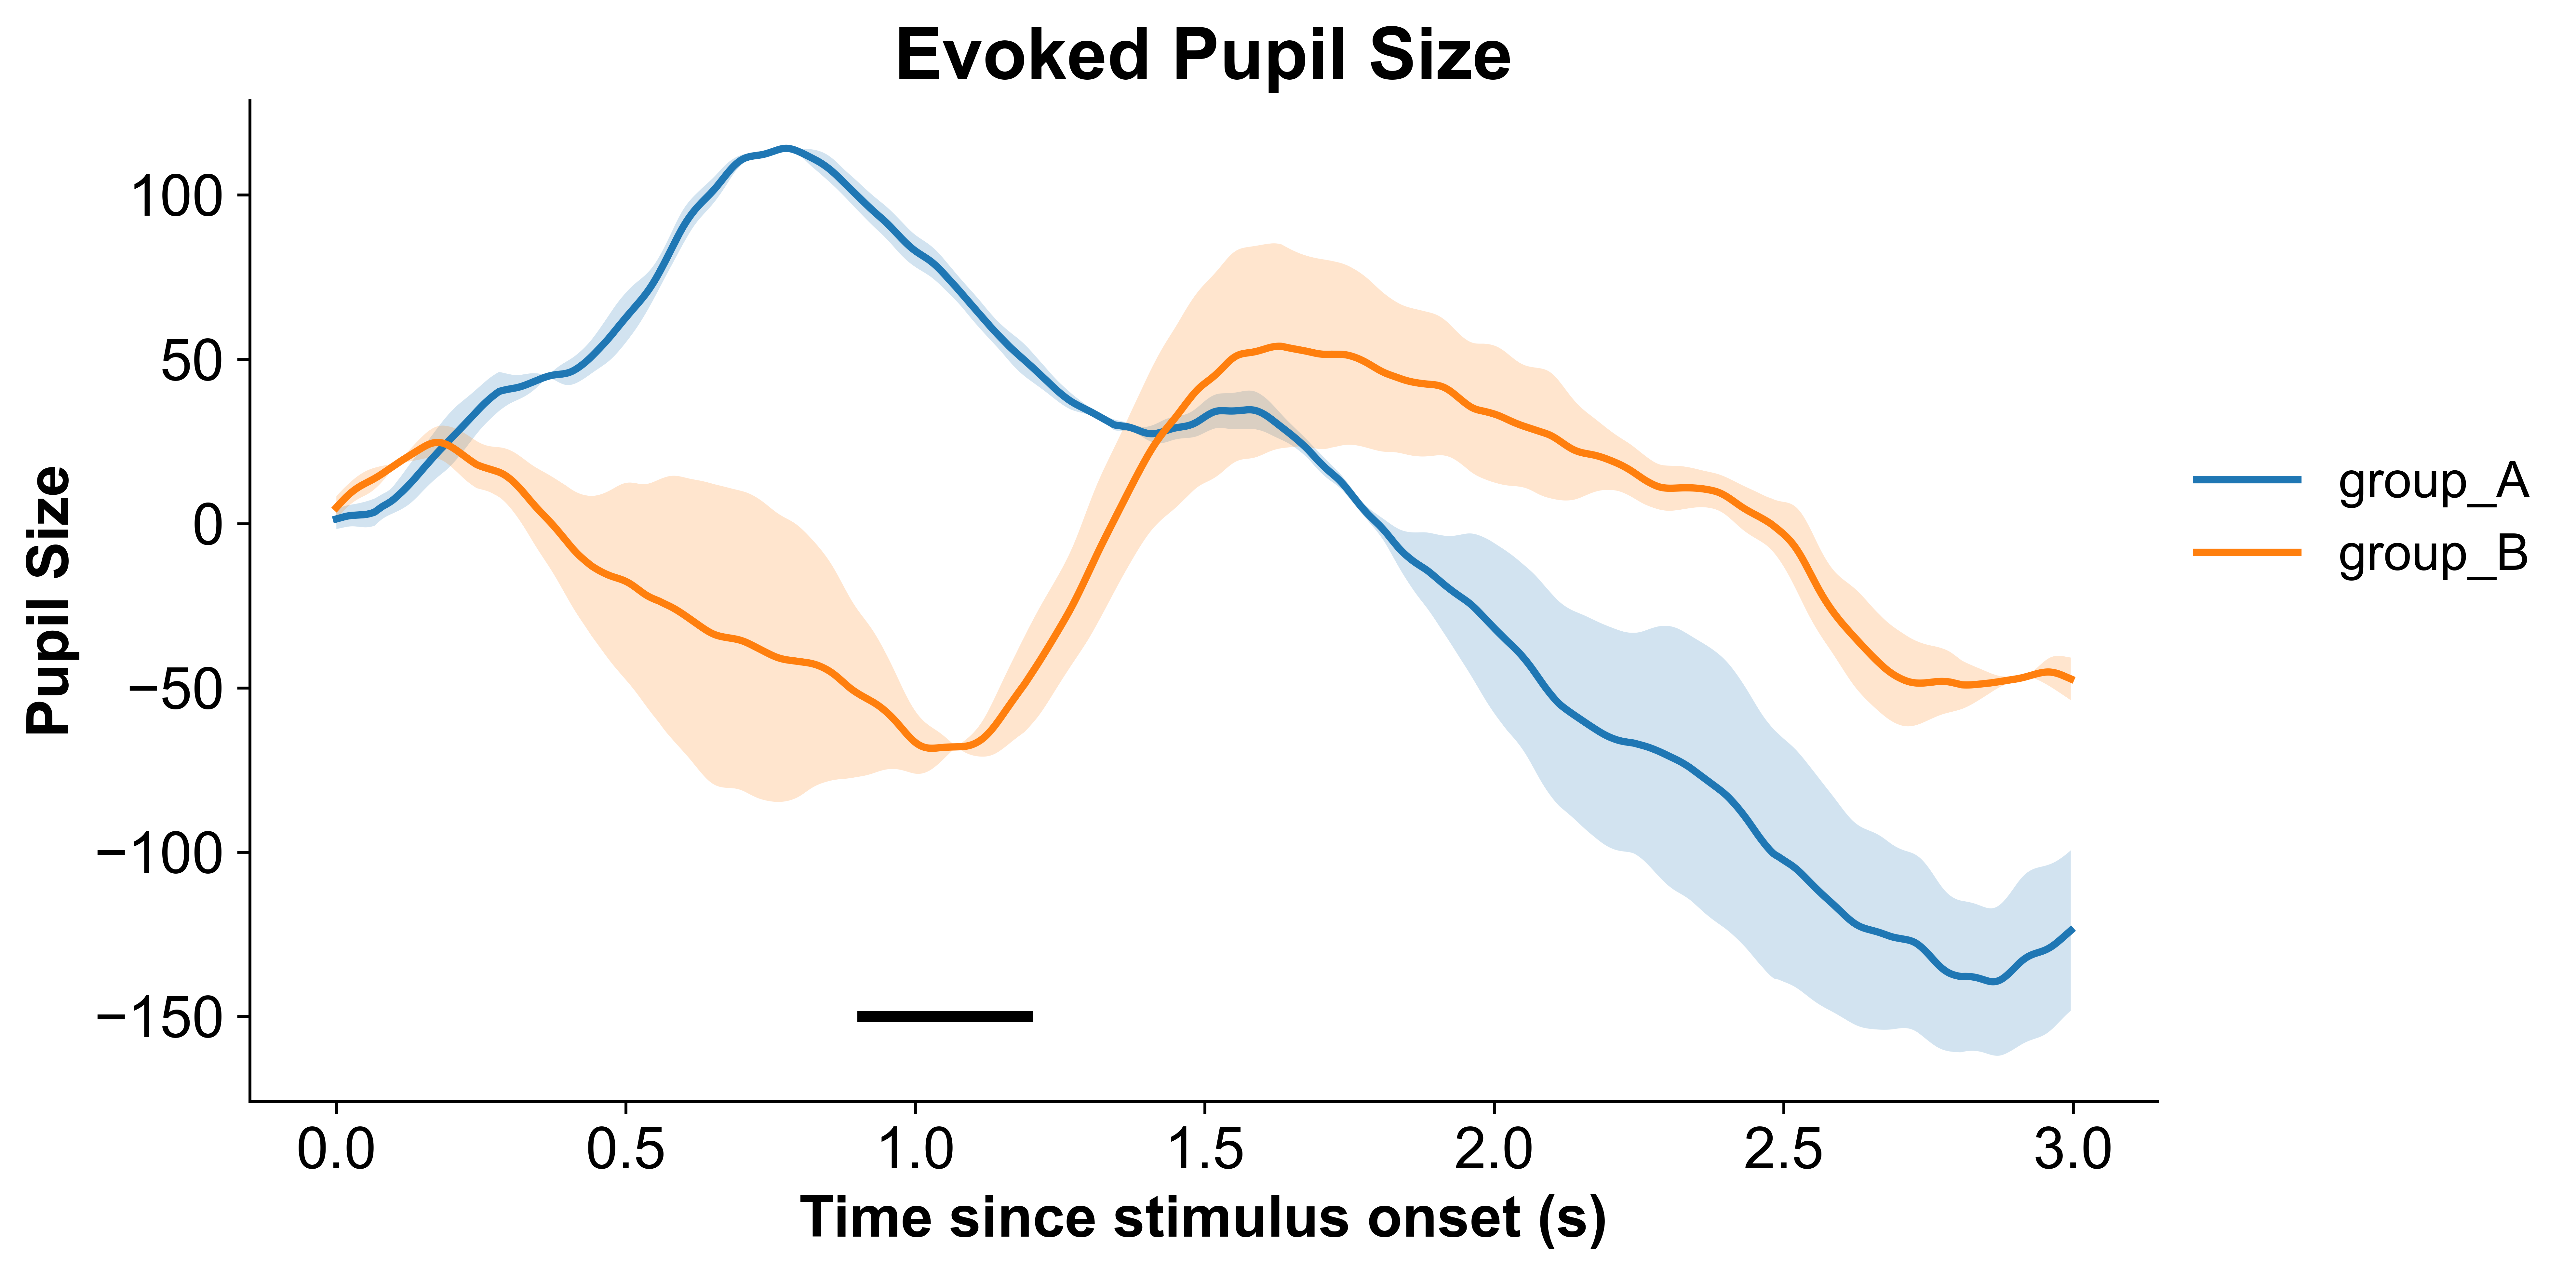

In [123]:
# Add clusters to the original plot
data, (fig, ax) = p.plot_evoked(data='final_data', 
                                agg_by='participant', # aggregate by participant
                                condition='group', 
                                pupil_col='pp_final', 
                                error='sem')

t = np.arange(data['group_A'].shape[1]) / 1000

# plot clusters
for cluster in clusters:
    ax.plot(t[cluster], [-150]*len(t[cluster]), color='black', linewidth=3)